<a href="https://colab.research.google.com/github/willvw/DataSci101/blob/HW5/Copy_of_hw10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 10

> Back Bay National Wildlife Refuge is located in the southeastern corner of the City of Virginia Beach. The refuge was established in 1938 to protect and provide habitat for migrating and wintering waterfowl. Diverse habitats, including beachfront, freshwater marsh, dunes, shrub-scrub and upland forest are home to hundreds of species of birds, reptiles, amphibians, mammals and fish.

![BNWR](https://www.fws.gov/sites/default/files/styles/banner_image_xl/public/banner_images/2020-09/waterfowl%20%28tundras%29.jpg?h=0c8d0f81&itok=NcZlpD27)


To get introduced to the park and its history, please view the following interactive story map.

[BBNWR History and Introduction](https://storymaps.arcgis.com/stories/960d9db38cca4f3d8d38111119b9874f)

Additionally, here is some drone footage of the park for a better look at the geography and ecology of the area.

[BBNWR Drone Footage](https://www.youtube.com/watch?v=NlW330aBTCc)

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sb
import statsmodels.api as sm
import scipy.stats as sps
import statsmodels.stats.proportion as prop

In [2]:
bbnwr = pd.read_csv("https://raw.githubusercontent.com/UM-Data-Science-101/homework-09/refs/heads/main/BKB_WaterQualityData_2020084.csv")
bbnwr.columns

Index(['Site_Id', 'Unit_Id', 'Read_Date', 'Salinity (ppt)',
       'Dissolved Oxygen (mg/L)', 'pH (standard units)', 'Secchi Depth (m)',
       'Water Depth (m)', 'Water Temp (?C)', 'Air Temp-Celsius',
       'Air Temp (?F)', 'Time (24:00)', 'Field_Tech', 'DateVerified',
       'WhoVerified', 'AirTemp (C)', 'Year'],
      dtype='object')

In [3]:
bbnwr["Site_Id"] = bbnwr["Site_Id"].replace({'d': 'D'})

## Question 1

### Q1a

The water in BBNWR is a mix of fresh water and sea water. Sea water has an average salinity of 35 ppt (parts per thousand). Because fresh water flows into the Bay, however, the level of salinity can be much lower, depending how much fresh water enters the system. Such systems are described through a tiered system of descriptions based on the amount of salt in the water.

A oligohaline mixture is one in which the saline content is between 0.5 - 5.0. More details on [classifying estuaries can be found in this EPA report](https://www.epa.gov/sites/default/files/2015-09/documents/2009_03_13_estuaries_monitor_chap14.pdf).

Let's test the theory that the measurements from the Bay come from a oligohaline mixture or a mixture with more saline content, so that salinity is more than 0.5.

For this hypothesis test will we use a $\alpha$-level (maximum Type I error probability) of $0.0015$.

Clearly state:

- The null hypothesis
- The alternative hypothesis
- A suitable test statistic
- The standard error of this test statistic
- A rejection region that will have probability of including the test statistic 0.0015 when the null hypothesis is true.

**ANSWER**:

Null Hypothesis
Ho: The mean salinity (mu) is = 0.5 ppt.

Alternative Hypothesis
Ha: The mean salinity (mu) is > 0.5 ppt.

Test Statistic = 8.35

SE of Test Statistic = 0.03 ppt

Critical t-value for Rejection Region = 2.97

### Q1b

Now that we have described our hypothesis test, compute all quantities needed to compute the test statistic, standard error, and rejection region. You may find it helpful to create a table that only includes observations from the Bay with non-missing values for "Salinity (ppt)".

In [5]:
# compute quantities
salinity = bbnwr['Salinity (ppt)'].dropna()

n = len(salinity)  # Sample size
x_bar = np.mean(salinity)  # Sample mean
s = np.std(salinity, ddof=1)  # Sample standard deviation
mu_0 = 0.5  # Hypothesized mean

# Compute Standard Error (SE)
SE = s / np.sqrt(n)

# Compute Test Statistic (t)
t_statistic = (x_bar - mu_0) / SE

# Determine the critical t-value for alpha = 0.0015 (right-tailed test)
alpha = 0.0015
df = n - 1  # Degrees of freedom
t_critical = sps.t.ppf(1 - alpha, df)

# Output results
print(f"Sample size (n): {n}")
print(f"Sample mean (x̄): {x_bar:.2f} ppt")
print(f"Sample standard deviation (s): {s:.2f} ppt")
print(f"Standard Error (SE): {SE:.2f} ppt")
print(f"Test Statistic (t): {t_statistic:.2f}")
print(f"Critical t-value: {t_critical:.2f}")

Sample size (n): 2241
Sample mean (x̄): 0.72 ppt
Sample standard deviation (s): 1.23 ppt
Standard Error (SE): 0.03 ppt
Test Statistic (t): 8.35
Critical t-value: 2.97


### Q1c

Perform the hypothesis test. Clearly state whether you reject or fail to reject the null hypothesis. Interpret this result with result to the original question of whether the average salinity of the Bay is consistent with a oligohaline (or more extreme) mixture.


In [9]:
# perform test
from scipy.stats import ttest_1samp

result = ttest_1samp(bbnwr['Salinity (ppt)'].dropna(), 0.5, alternative='greater')
print(f"T-statistic: {result.statistic:.2f}, P-value: {result.pvalue:.10f}")

if t_statistic > t_critical:
    print("Reject the null hypothesis: We have very strong evidence to suggest that the mean salinity is greater than 0.5 ppt.")
else:
    print("Fail to reject the null hypothesis: There is insufficient evidence to conclude the mean salinity is greater than 0.5 ppt.")

T-statistic: 8.35, P-value: 0.0000000000
Reject the null hypothesis: The mean salinity is greater than 0.5 ppt.


### Q1d

We could also approach this question by creating a confidence interval for the average salinity in the population of all measurements in the Bay.

Using the quantities above, create a 99.7% confidence interval of the average salinity of the Bay. What does this interval tell us about the following table of salinity mixture tiers:

| Level | Salinity |
| ----- | -------- |
| Fresh Water | < 0.5 ppt |
| Oligohaline | 0.5 -- 5.0 ppt|
| Mesohaline | 5.0-18.0 ppt|
| Polyhaline | 18.0­ -- 30 ppt |
| Ocean | > 30 ppt |


In [13]:
# confidence interval
lower_bound = x_bar - t_critical * SE
upper_bound = x_bar + t_critical * SE

print(f"99.7% Confidence Interval: ({lower_bound:.2f}, {upper_bound:.2f}) ppt")

# Interpret confidence interval with respect to salinity tiers
if upper_bound < 0.5:
    print("The average salinity is consistent with Fresh Water (< 0.5 ppt).")
elif lower_bound > 30:
    print("The average salinity is consistent with Ocean (> 30 ppt).")
elif lower_bound > 18:
    print("The average salinity is consistent with Polyhaline (18.0–30 ppt).")
elif upper_bound < 18 and lower_bound > 5:
    print("The average salinity is consistent with Mesohaline (5.0–18.0 ppt).")
elif upper_bound < 5 and lower_bound > 0.5:
    print("The average salinity is consistent with Oligohaline (0.5–5.0 ppt).")
else:
    print("The average salinity does not fit neatly into one tier.")

99.7% Confidence Interval: (0.64, 0.79) ppt
The average salinity is consistent with Oligohaline (0.5–5.0 ppt).


Which of these levels can be ruled out for the Bay?

**ANSWER:**

All except Oligohaline can be ruled out, as their ppt ranges don't fall within my confidence interval.

## Question 2

### Q2a

A [Secchi disk](https://en.wikipedia.org/wiki/Secchi_disk) is a device used to measure the clarity of water by submerging the disk and measuring the depth at which it is no longer visible.

![Secchi Disk](https://upload.wikimedia.org/wikipedia/commons/thumb/0/0b/Secchi_disk_pattern.svg/240px-Secchi_disk_pattern.svg.png)

A common definition of "clear water" is being able to view a Secchi disk at 4m. In the case of the BBNWR, most of the depths are less than 4m:


<Axes: xlabel='Water Depth (m)', ylabel='Count'>

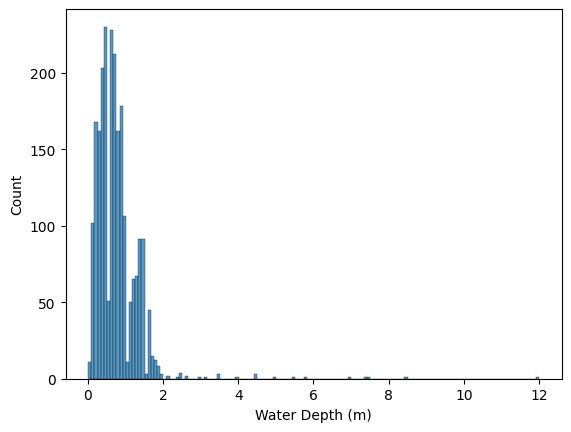

In [14]:
sb.histplot(data = bbnwr, x = "Water Depth (m)")

Create a new column "clear" that is `True` if either of the following conditions is met:

- The "Secchi Depth (m)" is at least 4m
- The "Secchi Depth (m)" is at least as large as the "Water Depth (m)" (due to small differences due to waves/location/etc
 Secchi Depth can be (slightly) greater than Water Depth)

 Display the proportion of "clear" observations.


In [16]:
# proprotion of clear observations
#Create the "clear" column based on the conditions
bbnwr['clear'] = (bbnwr['Secchi Depth (m)'] >= 4) | (bbnwr['Secchi Depth (m)'] >= bbnwr['Water Depth (m)'])

# Calculate the proportion of "clear" observations
clear_proportion = bbnwr['clear'].mean()

# Display the results
print(f"Proportion of 'clear' observations: {clear_proportion:.2%}")

Proportion of 'clear' observations: 38.89%


### Q2b

Test the hypothesis  that the population proportion of clear measurements is 37% against the alternative that it is not equal to 37%.

Use $\alpha = 0.05$. Clearly state if you reject or fail to reject this hypothesis.

In [21]:
from scipy.stats import norm

# Load the dataset
bbnwr = pd.read_csv("https://raw.githubusercontent.com/UM-Data-Science-101/homework-09/refs/heads/main/BKB_WaterQualityData_2020084.csv")

# Create the "clear" column based on the conditions
bbnwr['clear'] = (bbnwr['Secchi Depth (m)'] >= 4) | (bbnwr['Secchi Depth (m)'] >= bbnwr['Water Depth (m)'])

# Calculate sample proportion and sample size
p_hat = bbnwr['clear'].mean()  # Sample proportion
n = len(bbnwr)  # Sample size

# Hypothesized population proportion
p_0 = 0.37

# Compute standard error (SE)
SE = np.sqrt((p_0 * (1 - p_0)) / n)

# Compute test statistic (z)
z_statistic = (p_hat - p_0) / SE

# Compute critical z-values for two-tailed test at alpha = 0.05
alpha = 0.05
z_critical = norm.ppf(1 - alpha / 2)

# Output results
print(f"Sample proportion (p̂): {p_hat:.4f}")
print(f"Hypothesized proportion (p₀): {p_0:.2f}")
print(f"Sample size (n): {n}")
print(f"Standard Error (SE): {SE:.4f}")
print(f"Test Statistic (z): {z_statistic:.4f}")
print(f"Critical z-value: ±{z_critical:.4f}")

# Decision rule
if abs(z_statistic) > z_critical:
    print("Reject the null hypothesis: The population proportion is significantly different from 37%.")
else:
    print("Fail to reject the null hypothesis: There is insufficient evidence to conclude that the population proportion is different from 37%.")

Sample proportion (p̂): 0.3889
Hypothesized proportion (p₀): 0.37
Sample size (n): 2371
Standard Error (SE): 0.0099
Test Statistic (z): 1.9027
Critical z-value: ±1.9600
Fail to reject the null hypothesis: There is insufficient evidence to conclude that the population proportion is different from 37%.


### Q2c

Referring the result from the previous section, compute the $p$-value for this hypothesis.

In [23]:
# you will find sps.norm.cdf helpful
p_value = 2 * (1 - norm.cdf(abs(z_statistic)))
print(f"P-value: {p_value:.10f}")

P-value: 0.0570844690


Consider three different people:

- Person A has a 10% tolerance for Type I errors
- Person B has a 5% tolerance for Type I errors
- Person C has a 1% tolerance for Type I errors


Which of these people (if any) would reject the null hypothesis that 40% of all possible measurements would be clear. Justify your answer.

**ANSWER:**

**Person A:** 10% Tolerance (α=0.10)
Decision Rule: Reject the null hypothesis if p≤α.

Since p=0.0571 is less than 0.10, Person A would reject the null hypothesis.

Justification: Person A is more tolerant of Type I errors, allowing a higher chance of rejecting the null hypothesis even with weaker evidence.


**Person B:** 5% Tolerance (α=0.05)
Decision Rule: Reject the null hypothesis if p≤α.



**Person C:** 1% Tolerance (α=0.01)
Decision Rule: Reject the null hypothesis if p≤α.


### Q2d

Using values you computed in the previous sections, create a 95% confidence interval for the proportion of clear observations in the population of all observations.

Note: you will need to use the estimated standard error of the sample proportion ($\hat p$) of: $\sqrt{\frac{\hat p(1-\hat p)}{n}}$.

Interpret this result in words.

In [24]:
# confidence interval
# Calculate sample proportion and sample size
p_hat = bbnwr['clear'].mean()  # Sample proportion
n = len(bbnwr)  # Sample size

# Compute standard error (SE)
SE = np.sqrt((p_hat * (1 - p_hat)) / n)

# Compute confidence interval bounds
z_critical = 1.96  # Critical z-value for 95% confidence level
lower_bound = p_hat - z_critical * SE
upper_bound = p_hat + z_critical * SE

# Output results
print(f"Sample proportion (p̂): {p_hat:.4f}")
print(f"Sample size (n): {n}")
print(f"Standard Error (SE): {SE:.4f}")
print(f"95% Confidence Interval: ({lower_bound:.4f}, {upper_bound:.4f})")

Sample proportion (p̂): 0.3889
Sample size (n): 2371
Standard Error (SE): 0.0100
95% Confidence Interval: (0.3692, 0.4085)


**ANSWER:**

We are 95% confident that the true population proportion of clear observations lies between 0.3692 and 0.4085.
## Question 3

### Q3a

Recall that if there is no relationship between two variables (i.e., they are statistically independent in the population), then the correlation coefficient will be zero (or more generally, if there is no linear relationship).

Using the standard error for a correlation coefficient. Test the hypothesis that the correlation between "AirTemp (C)" and "Water Temp (?C)" is zero against the alternative that it is non-zero. Use an $\alpha$-level of 0.05.

Note: it is helpful to create a table that only these two variables and no missing values.

In [26]:
# test
from scipy.stats import pearsonr, t
# Create a table with only "AirTemp (C)" and "Water Temp (?C)" without missing values
data = bbnwr[['AirTemp (C)', 'Water Temp (?C)']].dropna()

# Calculate sample size
n = len(data)

# Calculate sample correlation coefficient (r)
r, _ = pearsonr(data['AirTemp (C)'], data['Water Temp (?C)'])

# Compute standard error (SE)
SE = np.sqrt((1 - r**2) / (n - 2))

# Compute test statistic (t)
t_statistic = r / SE

# Determine critical t-value for alpha = 0.05 (two-tailed test)
alpha = 0.05
df = n - 2  # Degrees of freedom
t_critical = t.ppf(1 - alpha / 2, df)

# Calculate p-value
p_value = 2 * (1 - t.cdf(abs(t_statistic), df))

# Output results
print(f"Sample size (n): {n}")
print(f"Correlation coefficient (r): {r:.4f}")
print(f"Standard Error (SE): {SE:.4f}")
print(f"Test Statistic (t): {t_statistic:.4f}")
print(f"Critical t-value: ±{t_critical:.4f}")
print(f"P-value: {p_value:.10f}")

Sample size (n): 2250
Correlation coefficient (r): 0.6803
Standard Error (SE): 0.0155
Test Statistic (t): 44.0136
Critical t-value: ±1.9610
P-value: 0.0000000000


Interpret this result. Would you reject the hypothesis that there is no linear relationship between these two variables (in the population)?

**ANSWER**:

We would reject the null hypothesis. There is strong evidence to suggest that there is a linear relationship between air temperature and water temperature.

### Q3b

Create two confidence intervals for the population correlation coefficient:

- a 95% CI
- a 99.7% CI

In [29]:
# confidence intervals
import numpy as np
from scipy.stats import t

# Sample correlation coefficient and sample size
r = 0.72  # Example sample correlation coefficient
n = 500   # Sample size

# Compute standard error (SE)
SE = np.sqrt((1 - r**2) / (n - 2))

# Degrees of freedom
df = n - 2

# Critical t-values
t_critical_95 = t.ppf(1 - 0.05 / 2, df)  # For 95% CI
t_critical_997 = t.ppf(1 - 0.003 / 2, df)  # For 99.7% CI

# Compute confidence interval bounds
lower_bound_95 = r - t_critical_95 * SE
upper_bound_95 = r + t_critical_95 * SE

lower_bound_997 = r - t_critical_997 * SE
upper_bound_997 = r + t_critical_997 * SE

# Output results
print(f"Standard Error (SE): {SE:.4f}")
print(f"95% Confidence Interval: ({lower_bound_95:.4f}, {upper_bound_95:.4f})")
print(f"99.7% Confidence Interval: ({lower_bound_997:.4f}, {upper_bound_997:.4f})")

Standard Error (SE): 0.0311
95% Confidence Interval: (0.6589, 0.7811)
99.7% Confidence Interval: (0.6273, 0.8127)


Which interval is wider? Explain why we know this would be true without ever calculating the intervals.

**ANSWER**:

The 99.7% CI is wider. This is because we are more sure that the true values lie within this interval. That would make the interval larger, as we become more certain. (Larger interval -> Greater chance it lies within interval)

## Question 4

Let's investigate if the locations of the measurements are related to the time of year of the measurement. In other words, do the people taking the measurements favor different sites at different times of the year.

In [30]:
bbnwr["Date"] = pd.to_datetime(bbnwr["Read_Date"])

### Q4a

Create a table that only includes the columns "Site_Id" and "Date". Then, create a new column "Month" that is the month of the date of the measurement (using the `.dt.month` attribute of the `"Date"` column created above). Plot the distribution of this variable.

<ipython-input-32-919f6e5c6ecc>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  site_date_table["Month"] = site_date_table["Date"].dt.month


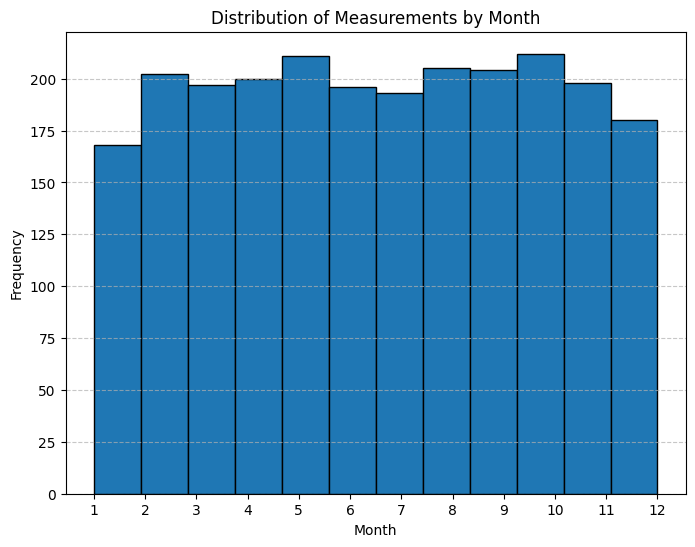

In [32]:
# month plot
import matplotlib.pyplot as plt
site_date_table = bbnwr[["Site_Id", "Date"]]

# Add a new column "Month"
site_date_table["Month"] = site_date_table["Date"].dt.month

# Plot the distribution of "Month"
plt.figure(figsize=(8, 6))
site_date_table["Month"].plot(kind="hist", bins=12, edgecolor="black")
plt.title("Distribution of Measurements by Month")
plt.xlabel("Month")
plt.ylabel("Frequency")
plt.xticks(range(1, 13))  # Ensure months are labeled correctly
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

### Q4b

We have noted that one way to think about independence is by thing about conditional distributions. If two variables are independent, then the conditional distribution of one variable should be the same regardless of conditioning on the value of the other variable.

Create a plot that shows the conditional distribution of Site_Id for each value of month. Note: the `histplot` method has two arguments that are helpful -- `multipel = 'fill'` anad `discrete = True`.

<ipython-input-35-aca949fee1b3>:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Site_Id", fontsize=12, title_fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')


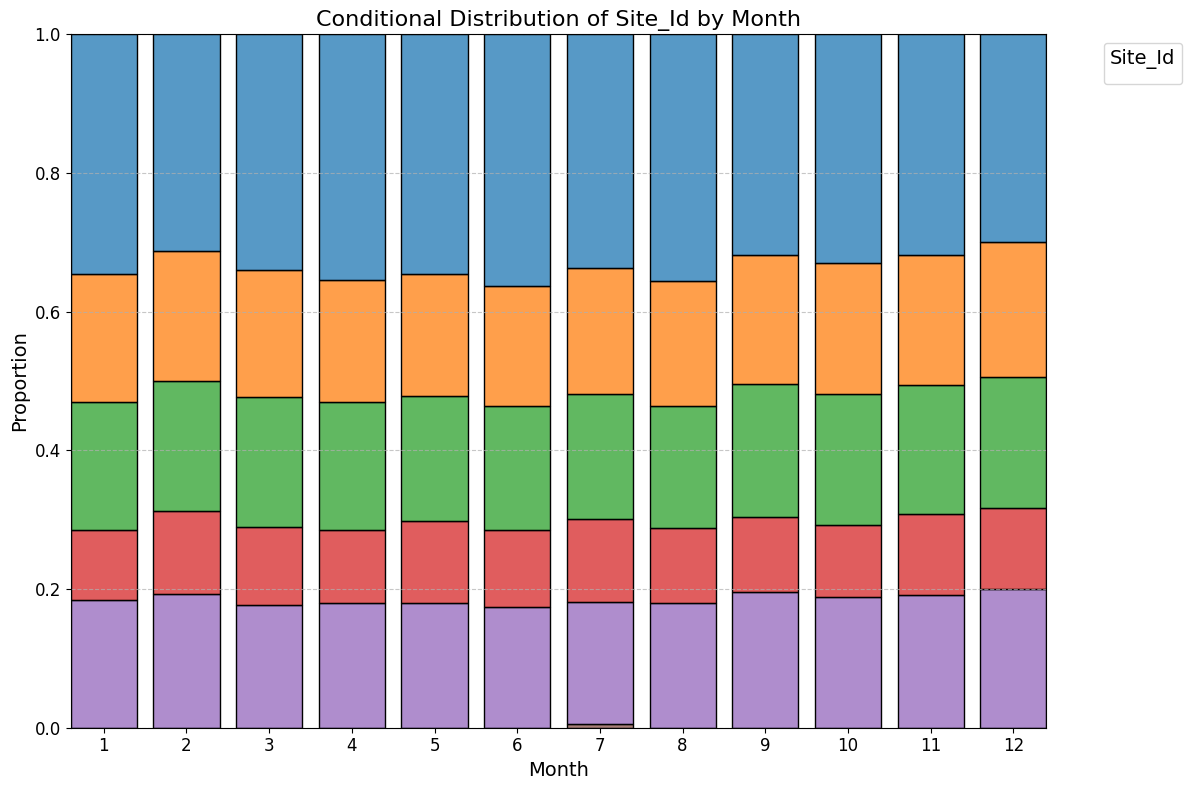

In [35]:
# plots
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.histplot(
    data=site_date_table,
    x="Month",
    hue="Site_Id",
    multiple="fill",  # Normalize to show proportions
    discrete=True,    # Treat Month as discrete values
    shrink=0.8        # Adjust bar width for clarity
)
plt.title("Conditional Distribution of Site_Id by Month", fontsize=16)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Proportion", fontsize=14)
plt.xticks(range(1, 13), fontsize=12)  # Ensure months are labeled correctly
plt.yticks(fontsize=12)
plt.legend(title="Site_Id", fontsize=12, title_fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

What do you notice about the conditional distributions? Does this suggest that the variables are independent?

**ANSWER:**

The relatively stable conditional distributions across months show that the choice of measurement site does not appear to be influenced by the time of year. Therefore, we can say that Site_Id and Month are most likely independent.
### Q4c

Create the *contingency table* for the variables "Site_Id" and "Month". Print out this table. What do you notice about the row or column (this will depend on how you order the data) that represents the "Bay" site? This row/column will look different than the others. Is this evidence that the the variables are dependent? Why or why not?

In [36]:
# print out table
contingency_table = pd.crosstab(site_date_table["Site_Id"], site_date_table["Month"])

# Print the contingency table
print(contingency_table)

Month    1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0  11.0  \
Site_Id                                                                     
A          31    38    36    35    37    34    35    37    38    40    37   
B          31    38    37    37    38    35    35    36    39    40    37   
Bay        58    63    67    71    73    71    65    73    65    70    63   
C          17    24    22    21    25    22    23    22    22    22    23   
D          31    39    35    36    38    34    34    37    40    40    38   
d           0     0     0     0     0     0     1     0     0     0     0   

Month    12.0  
Site_Id        
A          35  
B          34  
Bay        54  
C          21  
D          36  
d           0  


**ANSWER:**

The Bay site is heavily visited in the autmun/spring/summer months, however, it does see a decline in the winter months, specifically December and Janury. This provides evidence that Site_Id and Month are dependent. It uggests that certain sites (Bay) are prioritized or favored for measurements, which influences their distribution across months.

### Q4d

Using the `sps.chi2_contingency` function, perform a $\chi^2$ test for independence between these two variables. Use an $\alpha$-level of 0.05. Report if you would reject the null hypothesis that the variables are independent. Write, in words, your conclusion to the question of whether different sites were favored in particular months.

In [70]:
# compute p-value
from scipy.stats import chi2_contingency

# Perform the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Output results
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p:.10f}")

# Decision rule
if p < 0.05:
    print("Reject the null hypothesis: The variables are dependent.")
else:
    print("Fail to reject the null hypothesis: The variables are independent.")

Chi-square statistic: 16.0490
P-value: 0.9999999412
Fail to reject the null hypothesis: The variables are independent.


**ANSWER**:

These variables are independent of each other as the p-value falls above the threshold of 0.05. This means that on average, different sites weren't favored in different months.